<h1 style="color:#001069ff; border-bottom:3px solid #242f6dff; padding-bottom:8px;"> Tarefas de Visão Computacional </h1>

<h2 style="color:#001069;">📖 Principais Tarefas da Visão Computacional</h2>

A Visão Computacional busca ensinar as máquinas a "enxergarem" e interpretarem imagens e vídeos de forma semelhante à forma como humanos o fazem. Abaixo estão as três principais tarefas:

<h3 style="color:#242f6d;">1. Classificação de Imagem (Image Classification)</h3>
<ul>
<li><b>Objetivo:</b> Prever uma única categoria ou rótulo que descreva todo o conteúdo da imagem. O modelo responde: <i>"Qual é o objeto principal nesta imagem?"</i></li>
<li><b>Exemplo:</b> O sistema analisa a foto de um animal e determina se a imagem contém um <b>Cachorro</b>, um <b>Gato</b> ou um <b>Pássaro</b>.</li>
</ul>

<h3 style="color:#242f6d;">2. Detecção de Objetos (Object Detection)</h3>
<ul>
<li><b>Objetivo:</b> Além de descobrir <i>quais</i> objetos estão presentes, também identifica <i>onde</i> eles estão localizados. O modelo contorna os objetos usando caixas delimitadoras (<i>bounding boxes</i>).</li>
<li><b>Exemplo:</b> Uma câmera no para-brisa de um carro que identifica <b>pessoas</b>, <b>outros carros</b> e <b>semáforos</b> na via, colocando um retângulo ao redor de cada um deles.</li>
</ul>

<h3 style="color:#242f6d;">3. Segmentação de Imagem (Image Segmentation)</h3>
<ul>
<li><b>Objetivo:</b> Classificar a imagem dividindo-a <i>pixel a pixel</i>, desenhando máscaras e extraindo os contornos exatos do objeto. </li>
<li><b>Tipos de Segmentação:</b>
  <ul>
  <li><i>Semântica:</i> agrupa globalmente (ex: destaca todos os pixels que compõem "a rua" da "calçada").</li>
  <li><i>Instâncias:</i> diferencia vários objetos individuais da mesma categoria (ex: distingue o "carro 1", o "carro 2" e o "carro 3").</li>
  </ul>
</li>
<li><b>Exemplo:</b> Na área médica, delinear os pixels exatos de um <b>tumor maligno</b> em uma radiografia para planejar uma cirurgia.</li>
</ul>

<div style="padding:14px 18px; border-radius:8px; border-left:4px solid #242f6d; margin:10px 0;">
💡 <b>Resumo:</b> A <i>Classificação</i> diz "O QUE" é, a <i>Detecção</i> diz "O QUE e ONDE" e a <i>Segmentação</i> mapeia os pixels exatos do objeto!
</div>

<br>
<h2 style="color:#001069;">🤖 Classificando Imagens com a API do Gemini</h2>

Vamos agora utilizar o modelo mais atual da Google para analisar uma das imagens presentes na pasta `imagens`. A API do Gemini nos fornece acesso a modelos **multimodais** poderosos (que enxergam, ouvem e leem), sendo uma ótima forma de validar e extrair informações de imagens através de Visão Computacional + IA Generativa.

Estaremos utilizando a nova **SDK `google-genai`** e o modelo rápido e poderoso **`gemini-2.5-flash`**.

Para isso, o primeiro passo é instalar a SDK (se for a primeira vez, retire o `#` inicial e rode a célula):
```bash
# !pip install -q google-genai pillow matplotlib pydantic
```

E então importar as bibliotecas e definir sua *chave de API*:

In [26]:
import os
from dotenv import load_dotenv
from google import genai
from PIL import Image
import matplotlib.pyplot as plt
from pydantic import BaseModel, Field

# 1. Inicializa o cliente do Gemini.

load_dotenv()

api_key = os.getenv("GOOGLE_API_KEY")
if not api_key:
    print("ERRO: Variável de API não encontrada no arquivo .env")
else:
    client = genai.Client(api_key=api_key)
    print("API configurada com sucesso!")

API configurada com sucesso!


Agora, mostramos as imagens encontradas na pasta `imagens`.  

In [27]:
# 2. Carrega uma imagem da pasta local
img_folder = "imagens"
images = [img for img in os.listdir(img_folder) if img.endswith((".jpg", ".png", ".jpeg"))]
print(f"Imagens encontradas: {images}")

Imagens encontradas: ['bird.jpg', 'cats_dog.png', 'kitchen.png', 'pizza.png']


Vamos escolher uma imagem para analisar.

Exibindo imagens\bird.jpg


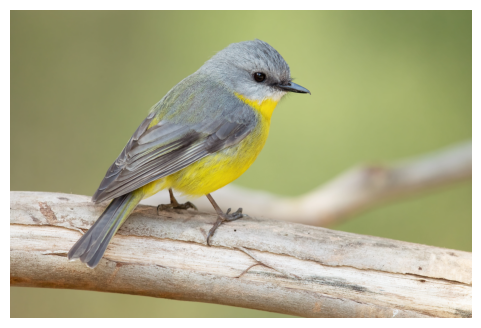

In [31]:
img_path = os.path.join(img_folder, "bird.jpg")
img = Image.open(img_path)
print(f"Exibindo {img_path}")
plt.figure(figsize=(6, 4))
plt.imshow(img)
plt.axis("off")
plt.show()

Usando Pydantic, podemos exigir que o Gemini devolva os dados em um formato estruturado (como um objeto JSON) em vez de apenas texto livre. Isso é super útil para pipelines de dados reais!

In [32]:
# 3. Definir a estrutura desejada usando Pydantic
class AnaliseImagem(BaseModel):
    objeto_principal: str = Field(description="Objeto ou Animal em destaque na imagem")
    descricao_detalhada: str = Field(description="Descrição detalhada da imagem")
    objetos_secundarios: list[str] = Field(description="Lista de Objetos ou Animais secundários na imagem")
    cenario: str = Field(description="Descrição curta do cenário/fundo")
    cores_predominantes: str = Field(description="Cores predominantes da imagem")
    iluminacao: str = Field(description="A iluminação parece ser natural ou artificial? É clara ou escura?")
    sentimento_da_imagem: str = Field(description="Análise de sentimento da imagem. A imagem está passando qual sentimento? alegria, tristeza, etc.")
    relacao_entre_objetos: str = Field(description="Como o objeto principal e os secundários estão interagindo ou posicionados?")

In [33]:
# 4. Envia o Prompt multimodal pedindo output estruturado
print("Processando imagem na IA do Google...\n")

response = client.models.generate_content(
    model='gemini-2.5-flash',
    contents=[
        img, 
        "Analise esta imagem focando nos animais/objetos, no cenário, e na iluminação."
    ],
    config={
        "response_mime_type": "application/json",
        "response_schema": AnaliseImagem,
    }
)

print("-" * 50)
print("✨ Resposta Estruturada do Gemini:\n")

# O retorno já vem nos moldes do JSON estruturado
print(response.text)

Processando imagem na IA do Google...

--------------------------------------------------
✨ Resposta Estruturada do Gemini:

{
  "objeto_principal": "Pássaro pequeno",
  "descricao_detalhada": "Um pássaro pequeno de plumagem cinza na cabeça e nas costas, com um peito e barriga amarelos vibrantes, está empoleirado em um galho horizontal. O pássaro tem olhos escuros e um bico fino e pontudo. Suas patas finas e escuras seguram o galho com firmeza.",
  "objetos_secundarios": [
    "Galho de árvore"
  ],
  "cenario": "O fundo é um borrão suave de verde claro e verde-oliva, sugerindo folhagem ou um ambiente natural desfocado.",
  "cores_predominantes": "Cinza, amarelo, verde-oliva, bege claro e marrom claro.",
  "iluminacao": "A iluminação é natural e clara, realçando os detalhes e as cores do pássaro e do ambiente sem criar sombras duras.",
  "sentimento_da_imagem": "A imagem transmite um sentimento de calma, serenidade e beleza natural, capturando um momento tranquilo na natureza.",
  "rel

<br>
<h2 style="color:#001069;">⚡ Classificando Imagens Localmente com Hugging Face</h2>

Agora vamos usar a biblioteca do Hugging Face para rodar os pesos de um modelo diretamente na nossa máquina local para classificar as imagens. O modelo escolhido é o `timm/mobilenetv3_small_100.lamb_in1k`, um modelo ultra-rápido focado em **Classificação de Imagem**.

Se for a primeira vez rodando o modelo localmente, instale as bibliotecas (você pode retirar o `#` e rodar a linha abaixo):
```bash
# !pip install -q transformers timm torch
```


In [34]:
import torch
import timm
from PIL import Image
import os
from urllib.request import urlopen
import matplotlib.pyplot as plt

print(f'PyTorch version: {torch.__version__}')
print(f'Timm version: {timm.__version__}')

c:\Users\joao_\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PyTorch version: 2.10.0+cpu
Timm version: 1.0.25


Vamos carregar o modelo pré-treinado e as categorias do ImageNet

In [35]:
# O nome do modelo conforme solicitado
model_name = 'mobilenetv3_small_100.lamb_in1k'

try:
    # Tenta carregar diretamente pelo nome do timm
    model = timm.create_model(model_name, pretrained=True)
except Exception as e:
    print(f"Erro ao carregar modelo normal, tentando via HF Hub: {e}")
    # Tenta carregar via Hugging Face Hub se falhar
    model = timm.create_model(f'hf-hub:timm/{model_name}', pretrained=True)

model.eval()

print(f"Modelo {model_name} carregado com sucesso.")

Modelo mobilenetv3_small_100.lamb_in1k carregado com sucesso.


c:\Users\joao_\AppData\Local\Programs\Python\Python313\Lib\site-packages\huggingface_hub\file_download.py:140: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\joao_\.cache\huggingface\hub\models--timm--mobilenetv3_small_100.lamb_in1k. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


Transformando as imagens e as padronizando para o modelo compeender melhor

In [36]:
# Configurando as transformações necessárias para o modelo
data_config = timm.data.resolve_model_data_config(model)
transform = timm.data.create_transform(**data_config, is_training=False)

print("Transformações configuradas:")
print(data_config)
print(transform)

Transformações configuradas:
{'input_size': (3, 224, 224), 'interpolation': 'bicubic', 'mean': (0.485, 0.456, 0.406), 'std': (0.229, 0.224, 0.225), 'crop_pct': 0.875, 'crop_mode': 'center'}
Compose(
    Resize(size=256, interpolation=bicubic, max_size=None, antialias=True)
    CenterCrop(size=(224, 224))
    MaybeToTensor()
    Normalize(mean=tensor([0.4850, 0.4560, 0.4060]), std=tensor([0.2290, 0.2240, 0.2250]))
)


In [37]:
# Download das labels do ImageNet (1000 classes)
labels_url = "https://raw.githubusercontent.com/pytorch/hub/master/imagenet_classes.txt"
with urlopen(labels_url) as f:
    categories = [line.decode("utf-8").strip() for line in f.readlines()]

print(f"{len(categories)} categorias carregadas.")

1000 categorias carregadas.


In [39]:
categories[:10]

['tench',
 'goldfish',
 'great white shark',
 'tiger shark',
 'hammerhead',
 'electric ray',
 'stingray',
 'cock',
 'hen',
 'ostrich']

Agora, faremos a **função de inferência**. Esta função recebe o caminho de uma imagem, processa e retorna as predições.

In [40]:
def classify_image(image_path):
    img = Image.open(image_path).convert('RGB')
    img_tensor = transform(img).unsqueeze(0)
    
    with torch.no_grad():
        output = model(img_tensor)
    
    # Converte output em probabilidades
    probabilities = torch.nn.functional.softmax(output[0], dim=0)
    
    # Pega o Top 5
    top5_prob, top5_catid = torch.topk(probabilities, 5)
    
    return [(categories[top5_catid[i]], top5_prob[i].item()) for i in range(top5_prob.size(0))]

Executando para images na pasta `imagens`


Classificando: bird.jpg...


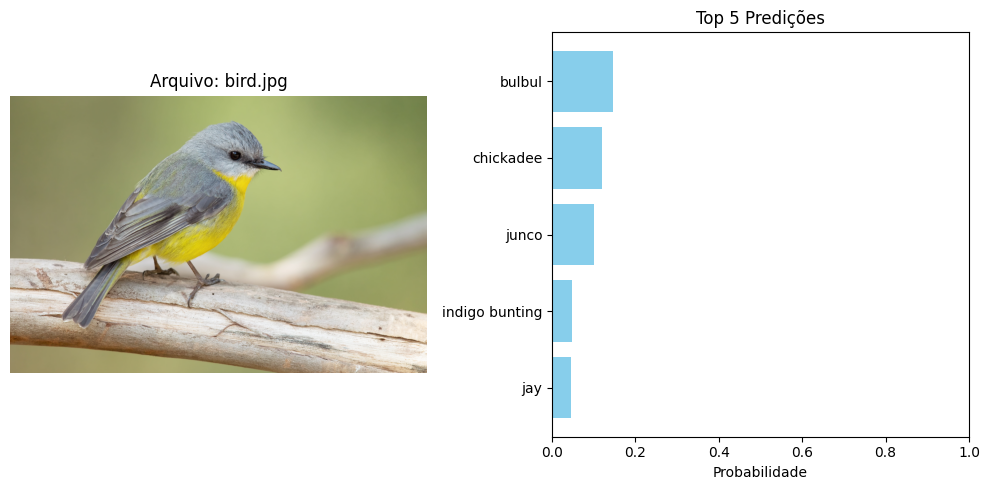

  - bulbul: 14.61%
  - chickadee: 11.93%
  - junco: 9.97%
  - indigo bunting: 4.83%
  - jay: 4.60%

Classificando: cats_dog.png...


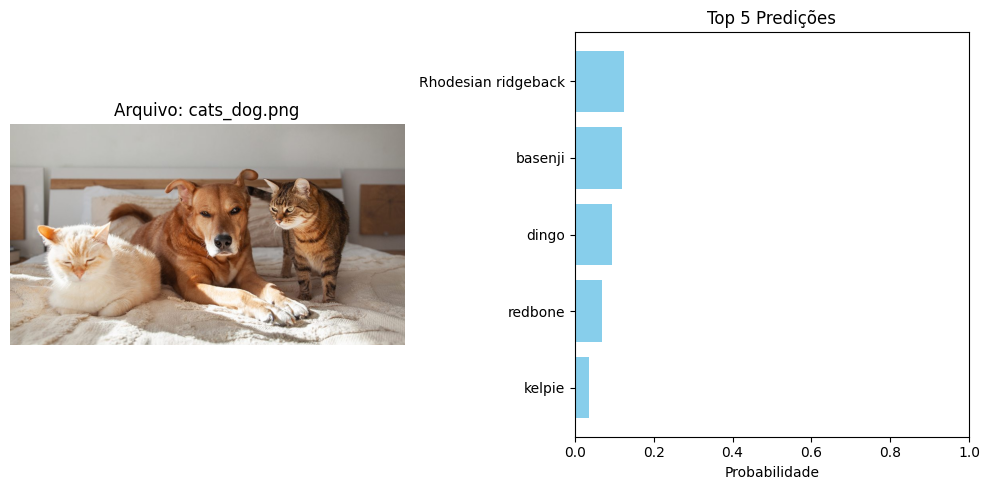

  - Rhodesian ridgeback: 12.38%
  - basenji: 12.06%
  - dingo: 9.30%
  - redbone: 6.86%
  - kelpie: 3.58%

Classificando: kitchen.png...


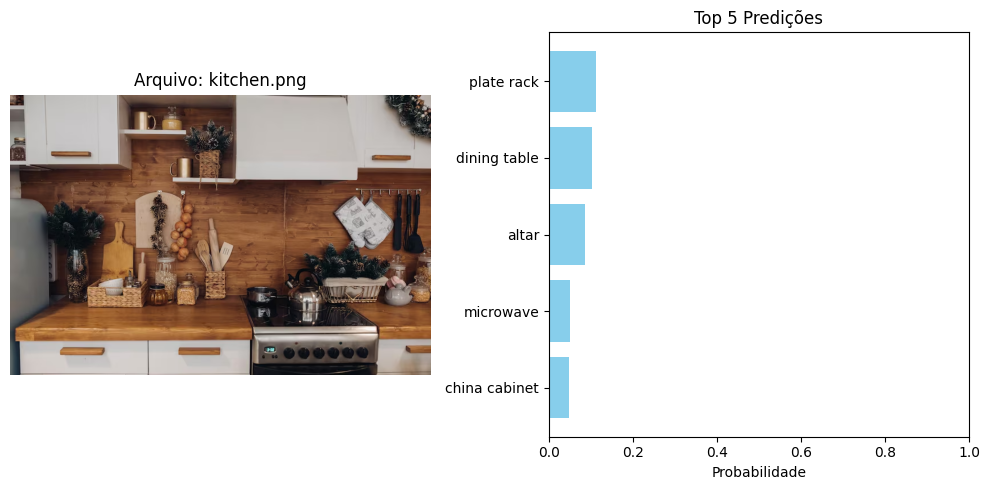

  - plate rack: 11.20%
  - dining table: 10.31%
  - altar: 8.53%
  - microwave: 5.08%
  - china cabinet: 4.85%

Classificando: pizza.png...


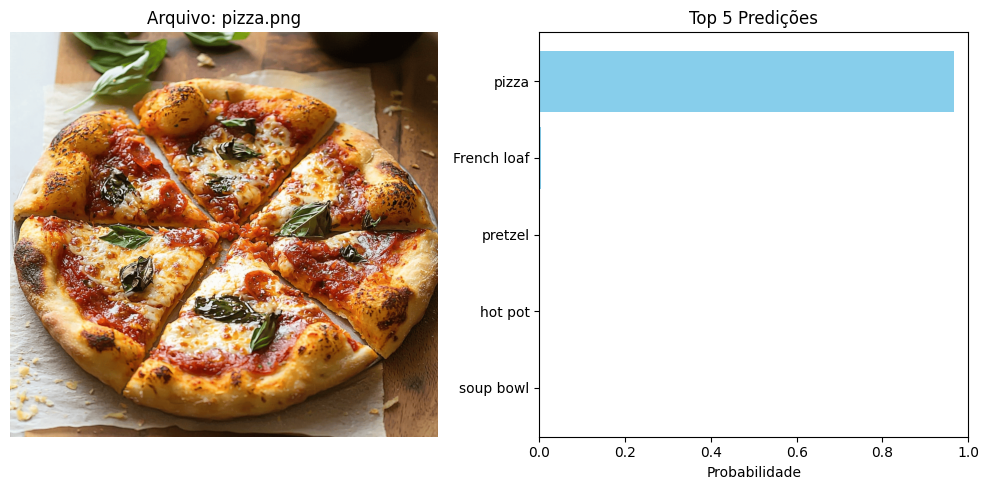

  - pizza: 96.76%
  - French loaf: 0.31%
  - pretzel: 0.20%
  - hot pot: 0.14%
  - soup bowl: 0.11%


In [41]:
image_folder = 'imagens'
valid_extensions = ('.png', '.jpg', '.jpeg', '.webp')
image_files = [f for f in os.listdir(image_folder) if f.lower().endswith(valid_extensions)]

if not image_files:
    print(f"Nenhuma imagem encontrada na pasta '{image_folder}'.")
else:
    for image_file in image_files:
        img_path = os.path.join(image_folder, image_file)
        print(f"\nClassificando: {image_file}...")
        
        results = classify_image(img_path)
        
        # Exibição básica
        plt.figure(figsize=(10, 5))
        
        # Mostrar a imagem
        plt.subplot(1, 2, 1)
        plt.imshow(Image.open(img_path))
        plt.title(f"Arquivo: {image_file}")
        plt.axis('off')
        
        # Mostrar as predições num gráfico de barras
        plt.subplot(1, 2, 2)
        labels = [r[0] for r in results][::-1] # Inverter para o gráfico ficar bonito
        probs = [r[1] for r in results][::-1]
        
        plt.barh(labels, probs, color='skyblue')
        plt.xlabel('Probabilidade')
        plt.title('Top 5 Predições')
        plt.xlim(0, 1) # Probabilidade de 0 a 1
        
        plt.tight_layout()
        plt.show()
        
        for cat, prob in results:
            print(f"  - {cat}: {prob*100:.2f}%")